# TCN Training Only (Clean)

This notebook is for **training only**.
It uses isolated `train_*` variables and a Sharpe-based checkpoint policy.

## 1) Connect to Colab VM and Sync Repo
Run this first.

In [1]:
# Fresh-start cleanup cell (run before importing project modules)
import gc
import shutil
import subprocess
import sys
from pathlib import Path

TRAIN_REPO_URL = "https://github.com/Dave-DKings/tcn_tape_vectorized_version.git"
TRAIN_REPO_DIR = Path("/content/tcn_tape_vectorized_version_clean")

# 1) Sync repo to latest main
if not (TRAIN_REPO_DIR / ".git").exists():
    subprocess.run(["git", "clone", TRAIN_REPO_URL, str(TRAIN_REPO_DIR)], check=True)

subprocess.run(["git", "-C", str(TRAIN_REPO_DIR), "fetch", "origin"], check=True)
subprocess.run(["git", "-C", str(TRAIN_REPO_DIR), "reset", "--hard", "origin/main"], check=True)

# 2) Remove old experiment outputs/checkpoints/cached data
purge_paths = [
    TRAIN_REPO_DIR / "tcn_fusion_results",
    TRAIN_REPO_DIR / "tcn_results",
    TRAIN_REPO_DIR / "tcn_att_results",
    TRAIN_REPO_DIR / "output_logs",
    TRAIN_REPO_DIR / "data" / "phase1_preparation_artifacts",
    TRAIN_REPO_DIR / "data" / "master_features_NORMALIZED.csv",
    TRAIN_REPO_DIR / "data" / "daily_ohlcv_assets.csv",              # forces fresh OHLCV download
    TRAIN_REPO_DIR / "data" / "processed_daily_macro_features.csv",   # forces fresh macro cache build
]

deleted = []
for p in purge_paths:
    if p.is_dir():
        shutil.rmtree(p, ignore_errors=True)
        deleted.append(str(p))
    elif p.is_file():
        p.unlink(missing_ok=True)
        deleted.append(str(p))

# 3) Remove Python/Jupyter cache folders
for cache_dir in TRAIN_REPO_DIR.rglob("__pycache__"):
    shutil.rmtree(cache_dir, ignore_errors=True)
for ckpt_dir in TRAIN_REPO_DIR.rglob(".ipynb_checkpoints"):
    shutil.rmtree(ckpt_dir, ignore_errors=True)

# 4) Clear loaded project modules from kernel memory
for mod in list(sys.modules.keys()):
    if mod.startswith("src.") or mod.startswith("src_"):
        del sys.modules[mod]
gc.collect()

print("✅ Fresh start complete")
print(f"Repo: {TRAIN_REPO_DIR}")
print(f"Deleted paths: {len(deleted)}")
for d in deleted:
    print(" -", d)

✅ Fresh start complete
Repo: /content/tcn_tape_vectorized_version_clean
Deleted paths: 0


In [2]:
#from pathlib import Path
import os

root = Path("/content/tcn_tape_vectorized_version_clean")
print("Exists:", root.exists())
print("CWD:", os.getcwd())

print("\nTop-level:")
for p in sorted(root.iterdir()):
    kind = "DIR " if p.is_dir() else "FILE"
    print(f" - [{kind}] {p.name}")

# Quick check for outputs/caches you expected to be deleted
targets = [
    "tcn_fusion_results",
    "tcn_results",
    "tcn_att_results",
    "output_logs",
    "data/phase1_preparation_artifacts",
    "data/master_features_NORMALIZED.csv",
    "data/daily_ohlcv_assets.csv",
    "data/processed_daily_macro_features.csv",
]
print("\nTarget paths:")
for t in targets:
    p = root / t
    print(f" - {t}: {'EXISTS' if p.exists() else 'MISSING'}")


Exists: True
CWD: /content

Top-level:
 - [DIR ] .git
 - [FILE] .gitignore
 - [FILE] RL Portfolio Optimization Feature Engineering.md
 - [FILE] RL_Portfolio_Optimization_Feature_Engineering.ipynb
 - [FILE] USAGE_GUIDE_ACTUARIAL.py
 - [FILE] __init__.py
 - [FILE] convert_md_to_ipynb.py
 - [DIR ] data
 - [FILE] debug_attention_weights.py
 - [DIR ] docs
 - [DIR ] eval
 - [DIR ] paper
 - [DIR ] prompts
 - [FILE] ra_kl_research_writeup.ipynb
 - [FILE] rcdcc_research_writeup.ipynb
 - [FILE] requirements.txt
 - [FILE] run_tcn_eval.py
 - [DIR ] src
 - [FILE] tcn_architecture_analysis.ipynb
 - [FILE] tcn_architecture_analysis_dual_head_redundancy.ipynb
 - [DIR ] tcn_documentation
 - [FILE] tcn_evaluation_only.ipynb
 - [FILE] technical_deep_dive_presentation.ipynb
 - [DIR ] tests
 - [FILE] traditional_portfolio_benchmarks.ipynb
 - [DIR ] training_scripts

Target paths:
 - tcn_fusion_results: MISSING
 - tcn_results: MISSING
 - tcn_att_results: MISSING
 - output_logs: MISSING
 - data/phase1_prepar

In [3]:
#!find /content/tcn_tape_vectorized_version_clean -maxdepth 3 | head -n 300

In [4]:
# Install project requirements in Colab VM
#import subprocess, sys
#from pathlib import Path

REPO_DIR = Path("/content/tcn_tape_vectorized_version_clean")
REQ_FILE = REPO_DIR / "requirements.txt"

if not REQ_FILE.exists():
    raise FileNotFoundError(f"Missing requirements file: {REQ_FILE}")

print("Using python:", sys.executable)
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-r", str(REQ_FILE)], check=True)

print("✅ Requirements installed")


Using python: /usr/bin/python3
✅ Requirements installed


In [5]:
# --- GPU sanity/setup for TensorFlow ---
import tensorflow as tf

!nvidia-smi -L

gpus = tf.config.list_physical_devices("GPU")
print("TF GPUs:", gpus)
if not gpus:
    raise RuntimeError("No GPU visible to TensorFlow. In Colab: Runtime -> Change runtime type -> GPU")

for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

USE_MIXED_PRECISION = False  # set True only after stable fp32 training
if USE_MIXED_PRECISION:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
else:
    tf.keras.mixed_precision.set_global_policy("float32")
print("Mixed precision policy:", tf.keras.mixed_precision.global_policy())

with tf.device("/GPU:0"):
    a = tf.random.normal((4096, 4096))
    b = tf.random.normal((4096, 4096))
    c = tf.matmul(a, b)

print("Matmul device:", c.device)
print("Default GPU device name:", tf.test.gpu_device_name())

GPU 0: NVIDIA H100 80GB HBM3 (UUID: GPU-873a23ff-16eb-cf19-6cc5-77fc7d08b70b)
TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "float32">
Matmul device: /job:localhost/replica:0/task:0/device:GPU:0
Default GPU device name: /device:GPU:0


## 2) Imports

In [6]:
import os, sys
from pathlib import Path

REPO_DIR = Path("/content/tcn_tape_vectorized_version_clean")

if not REPO_DIR.exists():
    raise FileNotFoundError(f"Repo not found: {REPO_DIR}")

# Set working directory
os.chdir(REPO_DIR)

# Add repo root to Python path
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

print("cwd:", os.getcwd())
print("sys.path[0]:", sys.path[0])

cwd: /content/tcn_tape_vectorized_version_clean
sys.path[0]: /content/tcn_tape_vectorized_version_clean


In [7]:
from copy import deepcopy
from pathlib import Path

import pandas as pd

from src.config import get_active_config
from src.csv_logger import CSVLogger
from src.notebook_helpers.tcn_phase1 import prepare_phase1_dataset, run_experiment6_tape

## 3) Base Config and Dataset Prep

In [8]:
# ------------------------------------------------------------------
# Global feature-audit plan enforcement (55 + 4 actuarial = 59)
# ------------------------------------------------------------------

def enforce_feature_audit_plan(cfg):
    fs = cfg.setdefault("feature_params", {}).setdefault("feature_selection", {})
    fs["enforce_allowlist"] = True
    fs["allowlist_apply_to_phase2"] = False

    allowlist = list(dict.fromkeys(fs.get("active_features_allowlist", []) or []))
    fs["active_features_allowlist"] = allowlist

    plan_name = fs.get("feature_audit_plan_name", "feature_audit_allowlist")
    expected_total = int(fs.get("feature_audit_expected_total_count", len(allowlist)))
    act_cols = [c for c in allowlist if str(c).startswith("Actuarial_")]

    print("✅ Feature audit plan configured")
    print("   plan:", plan_name)
    print("   allowlist count:", len(allowlist))
    print("   expected total:", expected_total)
    print("   actuarial in allowlist:", len(act_cols), act_cols)

    if len(allowlist) != expected_total:
        print("⚠️ Allowlist count differs from expected total. Check src/config.py")

    return cfg


In [9]:
TRAIN_RANDOM_SEED = 42

train_config = deepcopy(get_active_config("phase1"))

# 7-asset universe from diagnostics (keep + selected review set)
ASSET_UNIVERSE_7 = ["JPM", "CAT", "UNH", "GOOGL", "MSFT", "NEE", "XOM"]
train_config["ASSET_TICKERS"] = ASSET_UNIVERSE_7
train_config["NUM_ASSETS"] = len(ASSET_UNIVERSE_7)
train_config["require_all_configured_assets"] = True
print("✅ Training asset universe:", train_config["ASSET_TICKERS"])
print("   NUM_ASSETS:", train_config["NUM_ASSETS"])

# Enable regime-conditioned buy signal features
alpha_cfg = train_config.setdefault("feature_params", {}).setdefault("alpha_features", {})
regime_buy_cfg = alpha_cfg.setdefault("regime_buy_signal", {})
regime_buy_cfg.update({
    "enabled": True,
    "lookback_window": 252,
    "min_history": 40,
    "prior_alpha": 5.0,
    "prior_beta": 5.0,
    "buy_threshold": 0.55,
    "use_relative_to_market": True,
    "market_vol_short_window": 21,
    "market_vol_long_window": 126,
    "high_vol_ratio_threshold": 1.05,
})
print("✅ Regime buy signal cfg:", regime_buy_cfg)

# If strict allowlist is active, verify regime-buy features are present.
fs_cfg = train_config.setdefault("feature_params", {}).setdefault("feature_selection", {})
if bool(fs_cfg.get("enforce_allowlist", False)):
    allow = list(dict.fromkeys(fs_cfg.get("active_features_allowlist", []) or []))
    required = ["BuyProb_Regime", "BuyEdge_Regime", "BuyFlag_Regime"]
    missing = [feat for feat in required if feat not in allow]
    if missing:
        allow.extend(missing)
        fs_cfg["active_features_allowlist"] = allow
        fs_cfg["feature_audit_expected_total_count"] = len(allow)
        print("✅ Allowlist patched for missing regime-buy features:", missing)
    else:
        print("✅ Allowlist already includes regime-buy features")


# Optional: override analysis horizon
# train_config["ANALYSIS_END_DATE"] = "2025-09-01"

train_config = enforce_feature_audit_plan(train_config)

# Force fresh dataset build and market data re-download
if "train_phase1_data" in globals():
    del train_phase1_data

train_phase1_data = prepare_phase1_dataset(
    train_config,
    force_download=True,
    preparation_artifacts_dir="/content/tcn_tape_vectorized_version_clean/data_exports",
)




✅ Training asset universe: ['JPM', 'CAT', 'UNH', 'GOOGL', 'MSFT', 'NEE', 'XOM']
   NUM_ASSETS: 7
✅ Regime buy signal cfg: {'enabled': True, 'lookback_window': 252, 'min_history': 40, 'prior_alpha': 5.0, 'prior_beta': 5.0, 'buy_threshold': 0.55, 'use_relative_to_market': True, 'market_vol_short_window': 21, 'market_vol_long_window': 126, 'high_vol_ratio_threshold': 1.05}
✅ Allowlist already includes regime-buy features
✅ Feature audit plan configured
   plan: exp6_feature_audit_20260221_v2
   allowlist count: 59
   expected total: 59
   actuarial in allowlist: 4 ['Actuarial_Expected_Recovery', 'Actuarial_Prob_30d', 'Actuarial_Prob_60d', 'Actuarial_Reserve_Severity']
📊 Loading raw market data...
   ✅ Raw data shape: (38502, 7)
   ✅ Date range: 2003-09-02 00:00:00 → 2025-08-29 00:00:00

🔧 Computing multi-horizon log returns: [1, 5, 10, 21]
   ✅ Shape after returns: (38355, 11)

📈 Calculating 21-day rolling statistics

🧮 Computing technical indicators

🕯️ Adding candlestick geometry featur

   ✅ Actuarial columns in dataset: 4 (enabled=True)
   📋 Non-null counts: {'Actuarial_Expected_Recovery': 38264, 'Actuarial_Prob_30d': 38264, 'Actuarial_Prob_60d': 38264, 'Actuarial_Reserve_Severity': 38264}

✅ Final master DF shape: (38264, 66)
   ✅ Total features: 66
🧭 Feature audit plan: exp6_feature_audit_20260221_v2 (allowlist enabled)
   active feature count (phase1): 59
   ✅ expected active features: 59

✂️ FILTERING TO ANALYSIS PERIOD
   Filtering data to: 2003-09-02 → 2025-09-01
   ✅ Dates after filter: 5501 trading days
   ✅ Date range: 2003-10-20 00:00:00 to 2025-08-29 00:00:00
✂️  TIME-BASED TRAIN/TEST SPLIT (80/20 split)
   Train: 2003-10-20 → 2021-04-13 (4400 days, 17.5 years, 30557 rows)
   Test:  2021-04-14 → 2025-08-29 (1101 days, 4.4 years, 7707 rows)

🔧 NORMALISING FEATURES (standard scaler)

💾 Saving NORMALISED master dataframe to '/content/tcn_tape_vectorized_version_clean/data/master_features_NORMALIZED.csv'

💾 Saved preparation artifacts:
   raw OHLCV: /content/t

In [10]:
print("Train shape:", train_phase1_data.train_df.shape)
print("Test shape:", train_phase1_data.test_df.shape)

cols = train_phase1_data.train_df.columns
print("Total columns:", len(cols))

# quick sanity for common redundant groups
dup_like = [c for c in cols if c.endswith("_raw") or c.endswith("_unscaled")]
print("Potential redundant raw/unscaled cols:", len(dup_like))
print(dup_like[:20])

used_now = list(dict.fromkeys(train_phase1_data.data_processor.get_feature_columns("phase1")))
act_now = [c for c in used_now if c.startswith("Actuarial_")]
print("Model feature count (phase1):", len(used_now))
print("Actuarial feature count:", len(act_now), act_now)


Train shape: (30557, 66)
Test shape: (7707, 66)
Total columns: 66
Potential redundant raw/unscaled cols: 0
[]
Model feature count (phase1): 59
Actuarial feature count: 4 ['Actuarial_Expected_Recovery', 'Actuarial_Prob_30d', 'Actuarial_Prob_60d', 'Actuarial_Reserve_Severity']


In [ ]:
[i for i in cols]

In [11]:
train_phase1_data.train_df[['Actuarial_Prob_60d', 'Actuarial_Prob_30d']].head()

,Actuarial_Prob_60d,Actuarial_Prob_30d
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,1.0,1.0


In [12]:
used = set(train_phase1_data.data_processor.get_feature_columns("phase1"))
disabled = set(train_config["feature_params"]["feature_selection"]["disabled_features"])
act_used = sorted([c for c in used if c.startswith("Actuarial_")])

print("Used feature count:", len(used))
print("Actuarial used:", len(act_used), act_used)
print("Disabled that still in used:", sorted(disabled & used))  # should be []
print("VIX_zscore used?", "VIX_zscore" in used)


Used feature count: 59
Actuarial used: 4 ['Actuarial_Expected_Recovery', 'Actuarial_Prob_30d', 'Actuarial_Prob_60d', 'Actuarial_Reserve_Severity']
Disabled that still in used: []
VIX_zscore used? True


In [13]:
base_cols = ["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]
keep = [c for c in base_cols + list(used) if c in train_phase1_data.master_df.columns]

train_phase1_data.master_df = train_phase1_data.master_df[keep].copy()
train_phase1_data.train_df = train_phase1_data.train_df[keep].copy()
train_phase1_data.test_df  = train_phase1_data.test_df[keep].copy()

### 3.1) Asset Basket Quality Diagnostics

Scores each asset for long-horizon usefulness using coverage, Sharpe, uniqueness (low collinearity), downside diversification, and regime consistency.


In [14]:
# ------------------------------------------------------------------
# Asset-basket quality diagnostics (coverage, redundancy, consistency)
# ------------------------------------------------------------------
import numpy as np
import pandas as pd

def _eval_identify_asset_column(df: pd.DataFrame):
    for c in ["Ticker", "ticker", "tic", "asset", "Asset", "symbol", "Symbol"]:
        if c in df.columns:
            return c
    return None

def _eval_identify_return_column(df: pd.DataFrame):
    for c in ["LogReturn_1d", "log_return_1d", "Return_1d", "return_1d", "daily_return"]:
        if c in df.columns:
            return c
    return None

def analyze_asset_basket_quality(train_df: pd.DataFrame, min_days: int = 252, corr_pair_threshold: float = 0.90):
    if "Date" not in train_df.columns:
        raise ValueError("train_df must contain 'Date' column")

    asset_col = _eval_identify_asset_column(train_df)
    ret_col = _eval_identify_return_column(train_df)
    if asset_col is None:
        raise ValueError("Could not identify asset column")
    if ret_col is None:
        raise ValueError("Could not identify return column")

    df = train_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    if "log" in ret_col.lower():
        df["_simple_ret"] = np.expm1(df[ret_col].astype(float))
    else:
        df["_simple_ret"] = df[ret_col].astype(float)

    panel = (
        df.pivot_table(index="Date", columns=asset_col, values="_simple_ret", aggfunc="mean")
        .sort_index()
    )

    n_days_total = int(panel.shape[0])
    coverage_days = panel.notna().sum()
    coverage_ratio = coverage_days / max(n_days_total, 1)

    effective_min_days = int(max(126, min(min_days, n_days_total)))
    keep_assets = coverage_days[coverage_days >= effective_min_days].index.tolist()
    if len(keep_assets) < 3:
        raise ValueError(
            f"Too few assets with enough coverage (>= {effective_min_days} days). "
            f"Got {len(keep_assets)}."
        )

    panel = panel[keep_assets]

    ann_return = panel.mean(skipna=True) * 252.0
    ann_vol = panel.std(skipna=True) * np.sqrt(252.0)
    ann_sharpe = ann_return / ann_vol.replace(0.0, np.nan)

    basket_eqw = panel.mean(axis=1, skipna=True)
    corr_to_basket = panel.corrwith(basket_eqw)

    corr_mat = panel.corr(min_periods=max(40, effective_min_days // 4))
    avg_abs_corr_to_others = corr_mat.abs().replace(1.0, np.nan).mean(skipna=True)
    uniqueness = 1.0 - avg_abs_corr_to_others.fillna(1.0)

    down_mask = basket_eqw < 0.0
    if int(down_mask.sum()) >= 40:
        downside_corr = panel.loc[down_mask].corrwith(basket_eqw.loc[down_mask])
    else:
        downside_corr = pd.Series(index=panel.columns, data=np.nan, dtype=float)

    regime_consistency = {}
    yearly_sharpe_std = {}
    for asset in panel.columns:
        s = panel[asset].dropna()
        if s.empty:
            regime_consistency[asset] = np.nan
            yearly_sharpe_std[asset] = np.nan
            continue
        y_ret = s.groupby(s.index.year).mean() * 252.0
        y_vol = s.groupby(s.index.year).std() * np.sqrt(252.0)
        y_sh = (y_ret / y_vol.replace(0.0, np.nan)).dropna()
        if y_sh.empty:
            regime_consistency[asset] = np.nan
            yearly_sharpe_std[asset] = np.nan
        else:
            regime_consistency[asset] = float((y_sh > 0.0).mean())
            yearly_sharpe_std[asset] = float(y_sh.std()) if len(y_sh) > 1 else 0.0

    regime_consistency = pd.Series(regime_consistency)
    yearly_sharpe_std = pd.Series(yearly_sharpe_std)

    # Rank-normalized score components
    r_sharpe = ann_sharpe.rank(pct=True)
    r_unique = uniqueness.rank(pct=True)
    r_coverage = coverage_ratio.rank(pct=True)
    r_downside_div = (-downside_corr.fillna(0.0)).rank(pct=True)  # lower downside corr is better
    r_regime = regime_consistency.fillna(0.0).rank(pct=True)

    # Composite score for keep/prune analysis (long-horizon oriented)
    score = (
        0.30 * r_sharpe
        + 0.25 * r_unique
        + 0.15 * r_coverage
        + 0.15 * r_downside_div
        + 0.15 * r_regime
    )

    out = pd.DataFrame({
        "coverage_days": coverage_days,
        "coverage_ratio": coverage_ratio,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "ann_sharpe": ann_sharpe,
        "corr_to_eqw": corr_to_basket,
        "avg_abs_corr_to_others": avg_abs_corr_to_others,
        "uniqueness": uniqueness,
        "downside_corr_to_eqw": downside_corr,
        "regime_consistency_pos_year_sharpe": regime_consistency,
        "yearly_sharpe_std": yearly_sharpe_std,
        "basket_quality_score": score,
    }).sort_values("basket_quality_score", ascending=False)

    out["basket_quality_bucket"] = np.where(
        out["basket_quality_score"] >= 0.65,
        "keep",
        np.where(out["basket_quality_score"] >= 0.45, "review", "prune_candidate"),
    )

    # Highly redundant asset pairs
    redundant_pairs = []
    cols = list(corr_mat.columns)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            v = corr_mat.loc[a, b]
            if pd.notna(v) and abs(float(v)) >= corr_pair_threshold:
                redundant_pairs.append((a, b, float(v)))
    redundant_df = pd.DataFrame(redundant_pairs, columns=["asset_a", "asset_b", "corr"]).sort_values(
        "corr", ascending=False
    ) if redundant_pairs else pd.DataFrame(columns=["asset_a", "asset_b", "corr"])

    summary = {
        "n_days_total": n_days_total,
        "n_assets_total": int(train_df[asset_col].nunique()),
        "n_assets_scored": int(len(out)),
        "effective_min_days": effective_min_days,
        "keep_count": int((out["basket_quality_bucket"] == "keep").sum()),
        "review_count": int((out["basket_quality_bucket"] == "review").sum()),
        "prune_candidate_count": int((out["basket_quality_bucket"] == "prune_candidate").sum()),
    }

    return out, redundant_df, summary

asset_quality_df, asset_redundant_pairs_df, asset_quality_summary = analyze_asset_basket_quality(
    train_phase1_data.train_df,
    min_days=252,
    corr_pair_threshold=0.90,
)

print("📊 Asset Basket Quality Summary:", asset_quality_summary)
print("Top assets by quality score:")
display(asset_quality_df.head(12))

print("Bottom assets (prune candidates first):")
display(asset_quality_df.sort_values("basket_quality_score", ascending=True).head(12))

print("Highly redundant asset pairs (|corr| >= 0.90):")
if asset_redundant_pairs_df.empty:
    print("None")
else:
    display(asset_redundant_pairs_df.head(20))



📊 Asset Basket Quality Summary: {'n_days_total': 4400, 'n_assets_total': 7, 'n_assets_scored': 7, 'effective_min_days': 252, 'keep_count': 4, 'review_count': 0, 'prune_candidate_count': 3}
Top assets by quality score:


,coverage_days,coverage_ratio,ann_return,ann_vol,ann_sharpe,corr_to_eqw,avg_abs_corr_to_others,uniqueness,downside_corr_to_eqw,regime_consistency_pos_year_sharpe,yearly_sharpe_std,basket_quality_score,basket_quality_bucket
CAT,4400,1.000000,301.104958,90.617639,3.322807,0.685521,0.372741,0.627259,0.522047,1.0,0.920235,0.732143,keep
JPM,4400,1.000000,402.515940,130.085721,3.094236,0.699141,0.330894,0.669106,0.559140,1.0,1.004164,0.675000,keep
UNH,4400,1.000000,292.727817,100.478994,2.913324,0.672187,0.351350,0.648650,0.477041,1.0,0.882917,0.660714,keep
GOOGL,4157,0.944773,289.678715,97.657877,2.966261,0.613603,0.309499,0.690501,0.534989,1.0,0.938028,0.657143,keep
NEE,4400,1.000000,144.130978,64.617522,2.230525,0.664455,0.401369,0.598631,0.420842,1.0,0.556149,0.446429,prune_candidate
XOM,4400,1.000000,176.550598,71.490764,2.469558,0.664153,0.393283,0.606717,0.549606,1.0,1.385638,0.417857,prune_candidate
MSFT,4400,1.000000,215.760038,80.582159,2.677516,0.701008,0.403680,0.596320,0.547943,1.0,1.103768,0.410714,prune_candidate


Bottom assets (prune candidates first):


,coverage_days,coverage_ratio,ann_return,ann_vol,ann_sharpe,corr_to_eqw,avg_abs_corr_to_others,uniqueness,downside_corr_to_eqw,regime_consistency_pos_year_sharpe,yearly_sharpe_std,basket_quality_score,basket_quality_bucket
MSFT,4400,1.000000,215.760038,80.582159,2.677516,0.701008,0.403680,0.596320,0.547943,1.0,1.103768,0.410714,prune_candidate
XOM,4400,1.000000,176.550598,71.490764,2.469558,0.664153,0.393283,0.606717,0.549606,1.0,1.385638,0.417857,prune_candidate
NEE,4400,1.000000,144.130978,64.617522,2.230525,0.664455,0.401369,0.598631,0.420842,1.0,0.556149,0.446429,prune_candidate
GOOGL,4157,0.944773,289.678715,97.657877,2.966261,0.613603,0.309499,0.690501,0.534989,1.0,0.938028,0.657143,keep
UNH,4400,1.000000,292.727817,100.478994,2.913324,0.672187,0.351350,0.648650,0.477041,1.0,0.882917,0.660714,keep
JPM,4400,1.000000,402.515940,130.085721,3.094236,0.699141,0.330894,0.669106,0.559140,1.0,1.004164,0.675000,keep
CAT,4400,1.000000,301.104958,90.617639,3.322807,0.685521,0.372741,0.627259,0.522047,1.0,0.920235,0.732143,keep


Highly redundant asset pairs (|corr| >= 0.90):
None


### 3.2) Asset Correlation Heatmap\n
\n
Visualize pairwise asset return correlations (full sample and downside-only days).\n

Assets in heatmap: 7
Downside days used: 1590


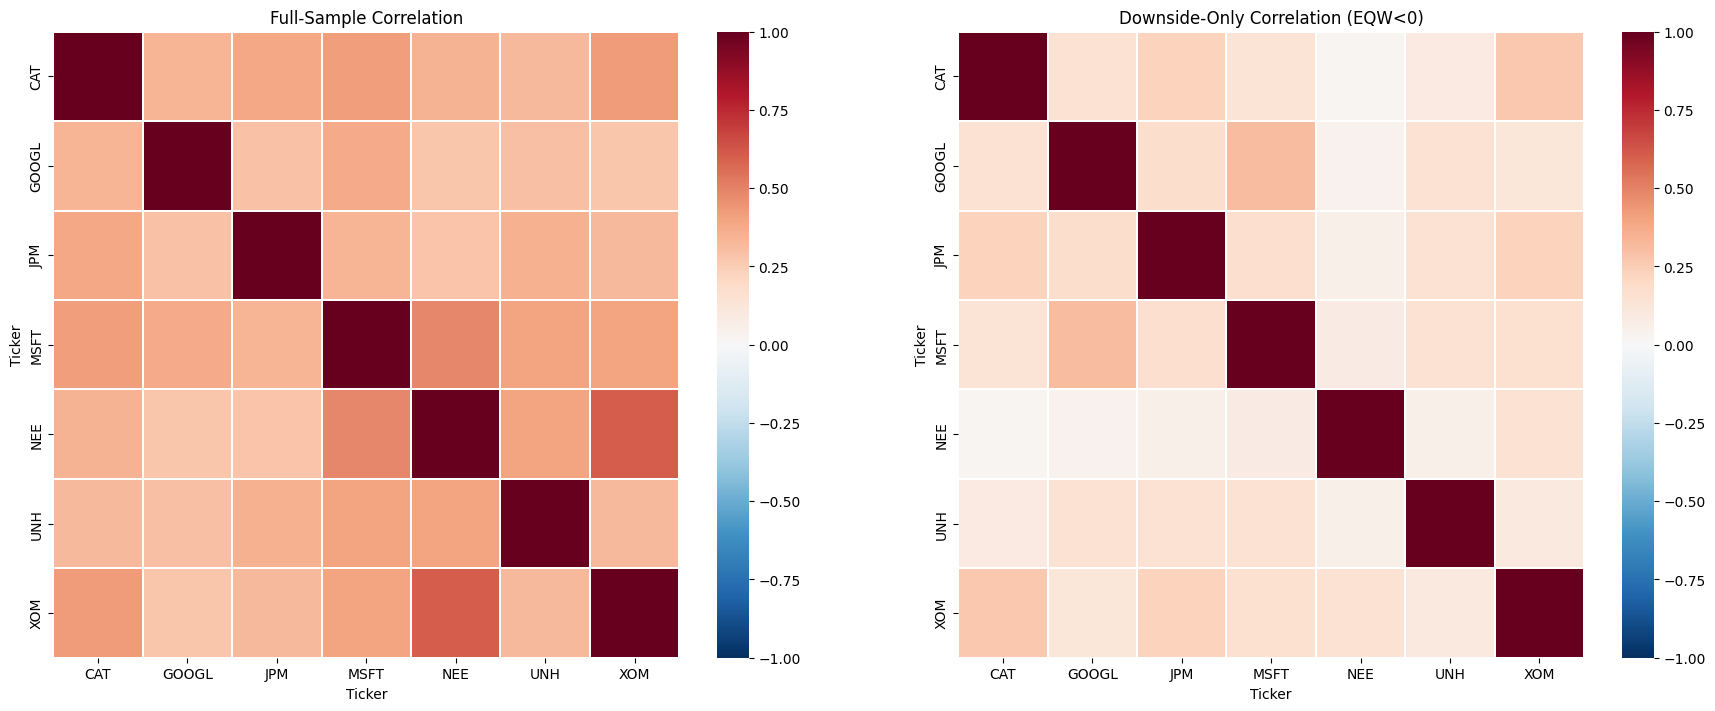

Top 15 absolute-correlation pairs (full sample):


,asset_a,asset_b,corr,abs_corr
19,NEE,XOM,0.604820,0.604820
15,MSFT,NEE,0.487366,0.487366
5,CAT,XOM,0.424720,0.424720
2,CAT,MSFT,0.414220,0.414220
17,MSFT,XOM,0.404510,0.404510
18,NEE,UNH,0.402296,0.402296
16,MSFT,UNH,0.401443,0.401443
1,CAT,JPM,0.386890,0.386890
7,GOOGL,MSFT,0.377192,0.377192
13,JPM,UNH,0.357151,0.357151


In [15]:
# ------------------------------------------------------------------
# Asset correlation heatmaps (full sample + downside regime)
# ------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    _HAS_SEABORN = True
except Exception:
    _HAS_SEABORN = False

asset_col = _eval_identify_asset_column(train_phase1_data.train_df)
ret_col = _eval_identify_return_column(train_phase1_data.train_df)

if asset_col is None or ret_col is None:
    raise ValueError("Could not identify asset/return columns for heatmap.")

corr_df = train_phase1_data.train_df[["Date", asset_col, ret_col]].copy()
corr_df["Date"] = pd.to_datetime(corr_df["Date"])

if "log" in ret_col.lower():
    corr_df["_simple_ret"] = np.expm1(corr_df[ret_col].astype(float))
else:
    corr_df["_simple_ret"] = corr_df[ret_col].astype(float)

ret_panel = (
    corr_df
    .pivot_table(index="Date", columns=asset_col, values="_simple_ret", aggfunc="mean")
    .sort_index()
)

# Keep only reasonably complete assets for stable correlations
min_cov = max(126, int(0.5 * len(ret_panel)))
valid_assets = ret_panel.notna().sum()
valid_assets = valid_assets[valid_assets >= min_cov].index.tolist()
ret_panel = ret_panel[valid_assets]

corr_full = ret_panel.corr(min_periods=60)

# Downside-only correlation: days where equal-weight basket is negative
basket_eqw = ret_panel.mean(axis=1, skipna=True)
down_mask = basket_eqw < 0.0
if int(down_mask.sum()) >= 40:
    corr_down = ret_panel.loc[down_mask].corr(min_periods=30)
else:
    corr_down = pd.DataFrame(index=ret_panel.columns, columns=ret_panel.columns, data=np.nan)

print(f"Assets in heatmap: {len(ret_panel.columns)}")
print(f"Downside days used: {int(down_mask.sum())}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

for ax, mat, title in [
    (axes[0], corr_full, "Full-Sample Correlation"),
    (axes[1], corr_down, "Downside-Only Correlation (EQW<0)"),
]:
    if _HAS_SEABORN:
        sns.heatmap(
            mat,
            ax=ax,
            cmap="RdBu_r",
            vmin=-1.0,
            vmax=1.0,
            center=0.0,
            square=True,
            linewidths=0.3,
            cbar=True,
            annot=False,
        )
    else:
        im = ax.imshow(mat.values.astype(float), cmap="RdBu_r", vmin=-1.0, vmax=1.0)
        ax.set_xticks(range(len(mat.columns)))
        ax.set_xticklabels(mat.columns, rotation=90)
        ax.set_yticks(range(len(mat.index)))
        ax.set_yticklabels(mat.index)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)

plt.show()

# Optional: print most redundant pairs from full-sample correlation
pairs = []
cols = list(corr_full.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]
        v = corr_full.loc[a, b]
        if pd.notna(v):
            pairs.append((a, b, float(v), abs(float(v))))

pairs_df = pd.DataFrame(pairs, columns=["asset_a", "asset_b", "corr", "abs_corr"]).sort_values("abs_corr", ascending=False)
print("Top 15 absolute-correlation pairs (full sample):")
display(pairs_df.head(15))



## 4) Training Overrides (Unified)

Single override cell with dual-head + de-constrained settings applied directly.


In [16]:
# ============================================================================
# NEXT RUN OVERRIDES (throughput-first + stable policy improvement)
# ============================================================================
from copy import deepcopy

train_config = deepcopy(train_config)  # or deepcopy(config) if that's your active object

tp = train_config["training_params"]
ap = train_config["agent_params"]
ppo = ap["ppo_params"]
env = train_config["environment_params"]
fp = train_config.setdefault("feature_params", {})
fund_cfg = fp.setdefault("fundamental_features", {})
act_cfg = fp.setdefault("actuarial_params", {})

# Hard requirement for this run: no fundamentals, actuarial ON.
fund_cfg["enabled"] = False
act_cfg["enabled"] = True

# ----------------------------------------------------------------------------
# 1) Core run shape
# ----------------------------------------------------------------------------
tp["max_total_timesteps"] = 150_000
tp["timesteps_per_ppo_update"] = 1008  # fallback
tp["num_parallel_envs"] = 4  # vectorized rollout collection

# Hard feasibility constraints (explicit)
tp["max_single_position"] = 20.0   # percent
tp["min_cash_position"] = 0.05     # 5%

tp["timesteps_per_ppo_update_schedule"] = [
    {"threshold": 0, "timesteps_per_update": 1008},   # 252/env × 4 envs
    {"threshold": 50_000, "timesteps_per_update": 1512},  # 378/env × 4 envs
    {"threshold": 100_000, "timesteps_per_update": 2016}, 
]

tp["batch_size_ppo_schedule"] = [
    {"threshold": 0, "batch_size": 252},
    {"threshold": 50_000, "batch_size": 336},
    {"threshold": 100_000, "batch_size": 504},
]



# ----------------------------------------------------------------------------
# 2) A2: deeper temporal receptive field (1D TCN only; 2D variant skipped)
# ----------------------------------------------------------------------------
ap["tcn_filters"] = [64, 96, 128, 128, 128]
ap["tcn_kernel_size"] = 5
ap["tcn_dilations"] = [1, 2, 4, 8, 16]
ap["tcn_dropout"] = 0.15

# ----------------------------------------------------------------------------
# 3) PPO stability (allow learning while keeping KL controlled)
# ----------------------------------------------------------------------------
ppo["num_ppo_epochs"] = 2
ppo["policy_clip"] = 0.15
ppo["target_kl"] = 0.03
ppo["kl_stop_multiplier"] = 1.50
ppo["minibatches_before_kl_stop"] = 2
ppo["max_grad_norm"] = 0.30

ppo["actor_lr"] = 2.5e-5
ppo["critic_lr"] = 1.2e-4
ppo["entropy_coef"] = 0.005

# Optional risk-aware actor auxiliaries (activate)
ppo["use_risk_aux_loss"] = True
ppo["risk_aux_return_feature_index"] = 0
ppo["risk_aux_cash_return"] = 0.0
ppo["risk_aux_sharpe_coef"] = 0.0
ppo["risk_aux_mvo_coef"] = 0.0
ppo["risk_aux_cvar_coef"] = 0.0015
ppo["risk_aux_cvar_alpha"] = 0.05
ppo["risk_aux_mvo_cov_ridge"] = 1e-3
ppo["risk_aux_mvo_long_only"] = True
ppo["risk_aux_mvo_risky_budget"] = 0.95

tp["actor_lr_schedule"] = [
    {"threshold": 0, "lr": 2.5e-5},
    {"threshold": 30_000, "lr": 1.5e-5},
    {"threshold": 60_000, "lr": 1.5e-5},
]

# ----------------------------------------------------------------------------
# 4) RA-KL (disable in early stage; re-enable only after baseline improves)
# ----------------------------------------------------------------------------
tp["ra_kl_enabled"] = False
tp["ra_kl_target_ratio"] = 1.0
tp["ra_kl_ema_alpha"] = 0.25
tp["ra_kl_gain"] = 0.03
tp["ra_kl_deadband"] = 0.20
tp["ra_kl_max_change_fraction"] = 0.05
tp["ra_kl_min_target_kl"] = 0.016
tp["ra_kl_max_target_kl"] = 0.030

# ----------------------------------------------------------------------------
# 5) Dirichlet + concentration controls
# ----------------------------------------------------------------------------
ap["dirichlet_alpha_activation"] = "softplus"
ap["dirichlet_logit_temperature"] = 1.0  # Keep static temperature neutral when adaptive is on
ap["dirichlet_alpha_cap"] = 20.0
ap["dirichlet_epsilon"] = {"max": 0.2, "min": 0.02}

ap["dirichlet_adaptive_temperature_enabled"] = True
ap["dirichlet_adaptive_temperature_base"] = 0.9
ap["dirichlet_adaptive_temperature_slope"] = 0.6
ap["dirichlet_adaptive_temperature_min"] = 0.8
ap["dirichlet_adaptive_temperature_max"] = 2.5

# A3/A4: richer alpha head + optional cross-asset mixer
ap["fusion_cross_asset_mixer_enabled"] = True
ap["fusion_cross_asset_mixer_layers"] = 2
ap["fusion_cross_asset_mixer_expansion"] = 2.0
ap["fusion_cross_asset_mixer_dropout"] = 0.10
ap["fusion_asset_identity_enabled"] = True
ap["fusion_context_cross_attention_enabled"] = True
ap["fusion_context_cross_attention_heads"] = 4
ap["fusion_context_cross_attention_dropout"] = 0.10
ap["fusion_per_asset_alpha_head"] = True
ap["fusion_alpha_head_hidden_dims"] = [128, 64]
ap["fusion_alpha_head_dropout"] = 0.05

env["concentration_penalty_scalar"] = 0.5
env["concentration_target_hhi"] = 0.12
env["penalty_budget_ratio"] = 0.0
env["top_weight_penalty_scalar"] = 0.0
env["action_realization_penalty_scalar"] = 0.0


# ----------------------------------------------------------------------------
# 5.5) Dual-head policy (Dirichlet + softmax/projection)
# ----------------------------------------------------------------------------
ap["dual_head_enabled"] = True
ap["dual_head_blend_schedule"] = [
    {"threshold": 0, "rho": 0.20},
    {"threshold": 30_000, "rho": 0.35},
    {"threshold": 60_000, "rho": 0.50},
]
ap["dual_head_eval_deterministic_rho"] = 0.90
ap["dual_head_eval_stochastic_rho"] = 0.60
ap["dual_head_projection_use_constraints"] = False
ap["dual_head_projection_max_single_position"] = 0.20
ap["dual_head_projection_min_cash_position"] = 0.05
ppo["dual_head_consistency_coef"] = 0.01

# ----------------------------------------------------------------------------
# 6) Turnover + execution smoothing
# ----------------------------------------------------------------------------
env["target_turnover"] = 0.40
env["turnover_penalty_scalar"] = 0.03
env["transaction_cost_pct"] = 0.001

tp["action_execution_beta_curriculum"] = {
    0: 0.08,
    30_000: 0.15,
    60_000: 0.25,
}
tp["evaluation_action_execution_beta"] = 0.20

tp["turnover_penalty_curriculum"] = {
    0: 0.03,
    10_000: 0.06,
    25_000: 0.08,
    40_000: 0.10,
}
tp["evaluation_turnover_penalty_scalar"] = 0.10

# ----------------------------------------------------------------------------
# 7) Episode horizon curriculum (keep cap late)
# ----------------------------------------------------------------------------
tp["use_episode_length_curriculum"] = True
tp["episode_length_curriculum_schedule"] = [
    {"threshold": 0, "limit": 252},
    {"threshold": 10_000, "limit": 504},
    {"threshold": 25_000, "limit": 756},
    {"threshold": 90_000, "limit": 1008},
]

# ----------------------------------------------------------------------------
# 8) Logging + checkpoints (reduce validation overhead)
# ----------------------------------------------------------------------------
tp["log_step_diagnostics"] = True
tp["update_log_interval"] = 10
tp["alpha_diversity_log_interval"] = 2
tp["alpha_diversity_warning_after_updates"] = 10
tp["alpha_diversity_warning_std_threshold"] = 0.25

tp["deterministic_validation_checkpointing_enabled"] = False
tp["deterministic_validation_eval_every_episodes"] = 5
tp["deterministic_validation_mode"] = "mean"
tp["deterministic_validation_episode_length_limit"] = None
tp["deterministic_validation_episode_length_limit_curriculum"] = [
    {"threshold": 0, "limit": 252},
    {"threshold": 30_000, "limit": 504},
    {"threshold": 70_000, "limit": 756},
    {"threshold": 100_000, "limit": 1008},
]
tp["deterministic_validation_sharpe_min"] = 0.5
tp["deterministic_validation_sharpe_min_delta"] = 0.005
tp["deterministic_validation_seed_offset"] = 10_000
tp["deterministic_validation_log_alpha_stats"] = True
tp["deterministic_validation_checkpointing_only"] = False

tp["high_watermark_checkpoint_enabled"] = True
tp["high_watermark_sharpe_threshold"] = 0.7 #0.5
tp["high_watermark_max_drawdown_abs_threshold"] = 0.25
tp["high_watermark_skip_on_deterministic_validation_trigger"] = True
tp["step_sharpe_checkpoint_enabled"] = False
tp["periodic_checkpoint_every_steps"] = 0
tp["rare_checkpoint_params"] = {"enable": False}
tp["tape_checkpoint_threshold"] = 999.0


# ----------------------------------------------------------------------------
# 9) Long-horizon upgrades (all enabled)
# ----------------------------------------------------------------------------
ap["recurrent_memory_enabled"] = True
ap["recurrent_memory_units"] = 64
ap["recurrent_memory_dropout"] = 0.10

ap["regime_conditioning_enabled"] = True
ap["regime_conditioning_hidden_dim"] = 32
ap["regime_conditioning_dropout"] = 0.0
ap["state_augmentation_enabled"] = True

ap["distributional_critic_enabled"] = True
ap["distributional_num_quantiles"] = 17

ppo["popart_enabled"] = True
ppo["popart_min_std"] = 1e-3

ppo["multi_horizon_reward_enabled"] = True
ppo["multi_horizon_reward_coef"] = 0.20
ppo["multi_horizon_reward_horizons"] = [21, 63, 126, 252]
ppo["multi_horizon_reward_weights"] = [0.15, 0.25, 0.30, 0.30]

ppo["risk_aux_cvar_adaptive_enabled"] = True
ppo["risk_aux_cvar_target"] = 0.020
ppo["risk_aux_cvar_adapt_lr"] = 0.01
ppo["risk_aux_cvar_min_coef"] = 0.0
ppo["risk_aux_cvar_max_coef"] = 0.02

# Disable overlapping drawdown/Gate-A constraints (CVaR is primary)
dd = env.setdefault("drawdown_constraint", {})
dd["enabled"] = False
env["tape_terminal_gate_a_enabled"] = False

tp["episode_length_curriculum_smooth_enabled"] = True
tp["episode_length_curriculum_overlap_steps"] = 10_000

tp["ppo_gamma_schedule"] = [
    {"threshold": 0, "gamma": 0.985},
    {"threshold": 50_000, "gamma": 0.992},
    {"threshold": 100_000, "gamma": 0.997},
]
tp["ppo_gae_lambda_schedule"] = [
    {"threshold": 0, "gae_lambda": 0.90},
    {"threshold": 50_000, "gae_lambda": 0.94},
    {"threshold": 100_000, "gae_lambda": 0.97},
]

tp["deterministic_validation_multi_horizon_enabled"] = False
tp["deterministic_validation_multi_horizon_limits"] = [252, 504, 756, 1008]
tp["deterministic_validation_multi_horizon_weights"] = [0.35, 0.30, 0.20, 0.15]
tp["deterministic_validation_multi_horizon_dd_penalty_coef"] = 0.25
tp["deterministic_validation_stochastic_sanity_enabled"] = False
tp["deterministic_validation_stochastic_sanity_runs"] = 3
tp["deterministic_validation_stochastic_sanity_episode_length_limit"] = 252
tp["deterministic_validation_stochastic_sanity_min_mean_sharpe"] = 0.0
tp["deterministic_validation_stochastic_sanity_max_sharpe_std"] = 1.5

print("✅ Applied unified override (base + dual-head + de-constrained)")
print("num_ppo_epochs:", ppo["num_ppo_epochs"])
print("target_kl:", ppo["target_kl"], "| kl_stop_multiplier:", ppo["kl_stop_multiplier"])
print("risk_aux:", {k: ppo[k] for k in ["use_risk_aux_loss", "risk_aux_sharpe_coef", "risk_aux_mvo_coef", "risk_aux_cvar_coef", "risk_aux_cvar_alpha", "risk_aux_return_feature_index", "risk_aux_mvo_risky_budget"]})
print("RA-KL:", {k: tp[k] for k in [
    "ra_kl_enabled", "ra_kl_gain", "ra_kl_deadband",
    "ra_kl_max_change_fraction", "ra_kl_min_target_kl", "ra_kl_max_target_kl"
]})
print("num_parallel_envs:", tp["num_parallel_envs"])
print("hard feasibility:", {"max_single_position": tp["max_single_position"], "min_cash_position": tp["min_cash_position"]})
print("action_execution_beta_curriculum:", tp["action_execution_beta_curriculum"])
print("turnover_penalty_curriculum:", tp["turnover_penalty_curriculum"])
print("det-val every episodes:", tp["deterministic_validation_eval_every_episodes"], "| horizon:", tp["deterministic_validation_episode_length_limit"])
print("det-val horizon curriculum:", tp["deterministic_validation_episode_length_limit_curriculum"])
print("high-watermark enabled:", tp["high_watermark_checkpoint_enabled"])
print("high-watermark thresholds: sharpe>=", tp["high_watermark_sharpe_threshold"], "| mdd<=", tp["high_watermark_max_drawdown_abs_threshold"])
print("high-watermark skip on det-validation trigger:", tp["high_watermark_skip_on_deterministic_validation_trigger"])
print("deterministic_validation_checkpointing_only:", tp["deterministic_validation_checkpointing_only"])
print("concentration:", env["concentration_penalty_scalar"], env["concentration_target_hhi"], env["top_weight_penalty_scalar"])

print("TCN stack:", ap["tcn_filters"], "| dilations:", ap["tcn_dilations"], "| dropout:", ap["tcn_dropout"])
print("Fusion mixer:", {k: ap[k] for k in ["fusion_cross_asset_mixer_enabled", "fusion_cross_asset_mixer_layers", "fusion_cross_asset_mixer_expansion", "fusion_cross_asset_mixer_dropout"]})
print("Fusion v2 cross-attn:", {k: ap[k] for k in ["fusion_asset_identity_enabled", "fusion_context_cross_attention_enabled", "fusion_context_cross_attention_heads", "fusion_context_cross_attention_dropout", "fusion_per_asset_alpha_head"]})
print("Fusion alpha head:", ap["fusion_alpha_head_hidden_dims"], "| dropout:", ap["fusion_alpha_head_dropout"])
print("dual_head:", {k: ap[k] for k in ["dual_head_enabled", "dual_head_blend_schedule", "dual_head_eval_deterministic_rho", "dual_head_eval_stochastic_rho", "dual_head_projection_use_constraints"]})
print("dual_head_consistency_coef:", ppo.get("dual_head_consistency_coef"))
print("fundamental_features.enabled:", bool(fund_cfg.get("enabled", False)))
print("actuarial_params.enabled:", bool(act_cfg.get("enabled", False)))

print("recurrent memory:", {k: ap[k] for k in ["recurrent_memory_enabled", "recurrent_memory_units", "recurrent_memory_dropout"]})
print("regime conditioning:", {k: ap[k] for k in ["regime_conditioning_enabled", "regime_conditioning_hidden_dim", "regime_conditioning_dropout", "state_augmentation_enabled"]})
print("distributional critic:", {k: ap[k] for k in ["distributional_critic_enabled", "distributional_num_quantiles"]})
print("PopArt + reward decomposition:", {k: ppo[k] for k in ["popart_enabled", "popart_min_std", "multi_horizon_reward_enabled", "multi_horizon_reward_coef", "multi_horizon_reward_horizons", "multi_horizon_reward_weights"]})
print("ppo gamma/gae schedules:", tp["ppo_gamma_schedule"], tp["ppo_gae_lambda_schedule"])
print("episode horizon smooth ramp:", tp["episode_length_curriculum_smooth_enabled"], "overlap:", tp["episode_length_curriculum_overlap_steps"])
print("drawdown enabled:", dd.get("enabled"), "| gate_a:", env.get("tape_terminal_gate_a_enabled"))
print("det-val multi-horizon+sanity:", {
    "enabled": tp["deterministic_validation_multi_horizon_enabled"],
    "limits": tp["deterministic_validation_multi_horizon_limits"],
    "weights": tp["deterministic_validation_multi_horizon_weights"],
    "dd_penalty": tp["deterministic_validation_multi_horizon_dd_penalty_coef"],
    "sanity_enabled": tp["deterministic_validation_stochastic_sanity_enabled"],
})



✅ Applied unified override (base + dual-head + de-constrained)
num_ppo_epochs: 2
target_kl: 0.03 | kl_stop_multiplier: 1.5
risk_aux: {'use_risk_aux_loss': True, 'risk_aux_sharpe_coef': 0.0, 'risk_aux_mvo_coef': 0.0, 'risk_aux_cvar_coef': 0.0015, 'risk_aux_cvar_alpha': 0.05, 'risk_aux_return_feature_index': 0, 'risk_aux_mvo_risky_budget': 0.95}
RA-KL: {'ra_kl_enabled': False, 'ra_kl_gain': 0.03, 'ra_kl_deadband': 0.2, 'ra_kl_max_change_fraction': 0.05, 'ra_kl_min_target_kl': 0.016, 'ra_kl_max_target_kl': 0.03}
num_parallel_envs: 4
hard feasibility: {'max_single_position': 20.0, 'min_cash_position': 0.05}
action_execution_beta_curriculum: {0: 0.08, 30000: 0.15, 60000: 0.25}
turnover_penalty_curriculum: {0: 0.03, 10000: 0.06, 25000: 0.08, 40000: 0.1}
det-val every episodes: 5 | horizon: None
det-val horizon curriculum: [{'threshold': 0, 'limit': 252}, {'threshold': 30000, 'limit': 504}, {'threshold': 70000, 'limit': 756}, {'threshold': 100000, 'limit': 1008}]
high-watermark enabled: True


In [17]:
# Optional experimental override (OFF by default)
# Keep this OFF for the aligned default pipeline.
EXPERIMENT_DISABLE_KL_GUARDS = False

if EXPERIMENT_DISABLE_KL_GUARDS:
    tp = train_config["training_params"]
    ppo = train_config["agent_params"]["ppo_params"]

    # Disable RA-KL controller (otherwise it keeps adjusting target_kl)
    tp["ra_kl_enabled"] = False

    # Disable KL early-stop gate in PPOAgentTF
    ppo["target_kl"] = 0.0

    # Optional (irrelevant once target_kl=0, but explicit)
    ppo["kl_stop_multiplier"] = 999.0
    ppo["minibatches_before_kl_stop"] = 9999
    print("⚠️ EXPERIMENT_DISABLE_KL_GUARDS=True (non-default experimental mode)")
else:
    print("ℹ️ EXPERIMENT_DISABLE_KL_GUARDS=False (keeping RA-KL + KL safeguards)")



ℹ️ EXPERIMENT_DISABLE_KL_GUARDS=False (keeping RA-KL + KL safeguards)


## 5) Run Training

In [18]:
RUN_TRAINING = True

if RUN_TRAINING:
    tp = train_config["training_params"]
    print("🚀 Starting training")
    print("Architecture:", train_config["agent_params"].get("actor_critic_type"))
    print("max_total_timesteps:", tp["max_total_timesteps"])
    print("num_parallel_envs:", tp.get("num_parallel_envs", 1))

    actuarial_cols = [c for c in train_phase1_data.master_df.columns if str(c).startswith("Actuarial_")]
    if not actuarial_cols:
        raise RuntimeError("Actuarial features missing in train_phase1_data.master_df")
    actuarial_non_null = {c: int(train_phase1_data.master_df[c].notna().sum()) for c in actuarial_cols}
    if any(v == 0 for v in actuarial_non_null.values()):
        raise RuntimeError(f"Actuarial features present but empty: {actuarial_non_null}")

    fundamental_cols = [c for c in train_phase1_data.master_df.columns if str(c).startswith("Fundamental_")]
    if fundamental_cols:
        raise RuntimeError(f"Fundamental columns still present (expected removed): {fundamental_cols}")

    print("✅ Actuarial feature check passed:", actuarial_non_null)
    print("✅ Fundamental feature check passed: none present")

    train_experiment6 = run_experiment6_tape(
        phase1_data=train_phase1_data,
        config=train_config,
        random_seed=TRAIN_RANDOM_SEED,
        csv_logger_cls=CSVLogger,
        use_covariance=True,
        architecture=train_config["agent_params"].get("actor_critic_type"),
        timesteps_per_update=tp.get("timesteps_per_ppo_update", 384),
        max_total_timesteps=tp["max_total_timesteps"],
    )

    print("✅ Training complete")
    print("checkpoint_prefix:", train_experiment6.checkpoint_path)
else:
    print("ℹ️ RUN_TRAINING=False")

🚀 Starting training
Architecture: TCN_FUSION
max_total_timesteps: 150000
num_parallel_envs: 4
✅ Actuarial feature check passed: {'Actuarial_Reserve_Severity': 38264, 'Actuarial_Prob_60d': 38264, 'Actuarial_Prob_30d': 38264, 'Actuarial_Expected_Recovery': 38264}
✅ Fundamental feature check passed: none present

EXPERIMENT 6: TCN_FUSION Enhanced + TAPE Three-Component
Architecture: TCN + Fusion
Results root: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results
Working dir: /content/tcn_tape_vectorized_version_clean
Covariance Features: Yes
🎯 REWARD SYSTEM: TAPE (Three-Component v3)
   Profile: BalancedGrowth
   Daily: Base + DSR/PBRS + Turnover_Proximity
   Terminal: mode=signed | baseline=0.20 | scalar=10.0 (clipped ±10.0)
   Gate A: disabled (Sharpe ≤ 0.00 or MDD ≥ 25.0% -> force non-positive terminal bonus)
   Neutral Band: enabled (±0.020 around baseline)
   🔄 Profile Manager: disabled (static profile only)
🎲 Experiment Seed: 6042 (Base: 42, Offset: 6000)
✅ Features: Enhance


📚 EPISODE HORIZON UPDATE at 2,016 steps:
   Episode horizon: 303 steps


      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00005_shp1p692_actor.weights.h5 (Sharpe=1.692, MDD=8.16%)
      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00008_shp1p749_actor.weights.h5 (Sharpe=1.749, MDD=6.50%)

📚 EPISODE HORIZON UPDATE at 3,024 steps:
   Episode horizon: 328 steps


      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00009_shp0p983_actor.weights.h5 (Sharpe=0.983, MDD=8.20%)
      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00011_shp0p776_actor.weights.h5 (Sharpe=0.776, MDD=7.97%)

📚 EPISODE HORIZON UPDATE at 4,032 steps:
   Episode horizon: 354 steps
      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00013_shp1p123_actor.weights.h5 (Sharpe=1.123, MDD=12.33%)
      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00014_shp0p948_actor.weights.h5 (Sharpe=0.948, MDD=8.06%)
      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/hi


📚 EPISODE HORIZON UPDATE at 8,064 steps:
   Episode horizon: 455 steps


...

      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00182_shp0p901_actor.weights.h5 (Sharpe=0.901, MDD=18.74%)
      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00183_shp0p919_actor.weights.h5 (Sharpe=0.919, MDD=24.02%)


      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00186_shp1p047_actor.weights.h5 (Sharpe=1.047, MDD=11.42%)
      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00187_shp0p947_actor.weights.h5 (Sharpe=0.947, MDD=19.58%)


      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00189_shp0p878_actor.weights.h5 (Sharpe=0.878, MDD=16.47%)


      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00193_shp1p187_actor.weights.h5 (Sharpe=1.187, MDD=11.05%)
      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00194_shp1p125_actor.weights.h5 (Sharpe=1.125, MDD=11.68%)
      💾 Sharpe-threshold checkpoint saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/high_watermark_checkpoints/exp6_tape_hw_ep00195_shp0p821_actor.weights.h5 (Sharpe=0.821, MDD=19.19%)


🔄 Update 108/108 | Step 150,000/150,000 | Episode 196 | Time: 10662.0s
   📊 Metrics: Return=+19.10% | Sharpe=0.224 | DD=51.38% | Turnover=6.62%
   🎚️ Intra-Step TAPE: potential=0.7145 | delta_reward=-0.0003
   🎯 Profile: BalancedGrowth
   🧠 Training: actor_loss=0.1110 | critic_loss=0.1211 | mean_adv=0.0000
   🧮 Loss Detail: critic_scaled=0.0605 | risk_aux_total=0.0438 | sharpe_proxy=0.0000 | sharpe_loss=0.0000 | mvo_loss=0.0000 | cvar_proxy=2.1901 | cvar_loss=0.0438 | cvar_coef=0.0200
   ⚙️ Optimizer: actor_lr=0.000015 | critic_lr=0.000120 | target_kl=0.0300 | rollout=2016 | batch_size=504 | gamma=0.9970 | gae_lambda=0.9700
   🔬 Alpha Diversity: mean=1.16 | std=0.26 | range=[0.47, 1.38]
   🎚️ Terminal TAPE snapshot=0.2322

✅ THREE-COMPONENT TAPE v3 training completed!
   Total episodes: 196
   Total timesteps: 150,000
   Training time: 10661.96s (177.70min)
📊 Training summary saved: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/logs/Exp6_TCN_FUSION_Enhanced_TAPE_trainin

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path

# 1) load latest step diagnostics
logs_dir = Path("/content/tcn_tape_vectorized_version_clean/tcn_fusion_results/logs")
step_csv = sorted(logs_dir.glob("*_step_diagnostics.csv"))[-1]
diag = pd.read_csv(step_csv)
diag["date"] = pd.to_datetime(diag["date"])

# 2) full-date coverage (all visited dates)
train_dates = pd.to_datetime(train_phase1_data.train_df["Date"]).drop_duplicates().sort_values()
seen_dates = diag["date"].dropna().drop_duplicates().sort_values()

print("Visited-date coverage:",
      f"{len(seen_dates)}/{len(train_dates)} = {len(seen_dates)/len(train_dates):.2%}")

# 3) start-date dispersion (episode_step==1 approximates resets)
starts = diag.loc[diag["episode_step"] == 1, "date"].dropna()
print("Num episode starts:", len(starts))
print("Unique start dates:", starts.nunique())

# 4) start distribution across timeline deciles
rank = starts.rank(method="average", pct=True)
bins = pd.cut(rank, bins=np.linspace(0,1,11), include_lowest=True)
print("Start-date decile distribution:")
print(bins.value_counts().sort_index())


Visited-date coverage: 4359/4400 = 99.07%
Num episode starts: 200
Unique start dates: 193
Start-date decile distribution:
date
(-0.001, 0.1]    20
(0.1, 0.2]       20
(0.2, 0.3]       20
(0.3, 0.4]       20
(0.4, 0.5]       20
(0.5, 0.6]       20
(0.6, 0.7]       20
(0.7, 0.8]       20
(0.8, 0.9]       20
(0.9, 1.0]       20
Name: count, dtype: int64


## 6) Inspect Latest Training Logs

In [20]:
TRAIN_RESULTS_ROOT = Path("/content/tcn_tape_vectorized_version_clean/tcn_fusion_results")
TRAIN_LOGS_DIR = TRAIN_RESULTS_ROOT / "logs"

episodes_files = sorted(TRAIN_LOGS_DIR.glob("*episodes*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
if not episodes_files:
    print(f"No episodes CSV found in {TRAIN_LOGS_DIR}")
else:
    train_episodes_path = episodes_files[0]
    train_episodes_df = pd.read_csv(train_episodes_path)
    print("Episodes file:", train_episodes_path)
    print("Rows:", len(train_episodes_df))
    display(train_episodes_df.tail(20))

Episodes file: /content/tcn_tape_vectorized_version_clean/tcn_fusion_results/logs/Exp6_TCN_FUSION_Enhanced_TAPE_training_20260301_043604_episodes.csv
Rows: 11


,update,timestep,episode,elapsed_time,episode_return_pct,episode_sharpe,episode_sortino,episode_max_dd,episode_volatility,episode_win_rate,...,actor_grad_norm,critic_grad_norm,alpha_min,alpha_max,alpha_mean,ratio_mean,ratio_std,drawdown_lambda_peak,episode_length,termination_reason
0,10,10080,24,765.142963,21.105418,0.637916,0.939126,10.982084,0.154218,52.422907,...,1.292840,0.190376,1.197307,1.420125,1.302638,0.940247,0.155187,0.0,455.0,episode_limit
1,20,20160,44,1461.807056,51.563423,1.409195,2.115154,8.301181,0.118760,53.608247,...,1.221650,0.319989,1.105700,1.357492,1.238061,0.938626,0.164639,0.0,583.0,episode_limit
2,30,30240,56,2177.635203,50.699864,0.600763,0.709350,34.507362,0.245184,54.701987,...,1.578287,1.107457,1.011514,1.352157,1.216646,0.950529,0.185923,0.0,756.0,episode_limit
3,40,40320,72,2889.309575,61.536419,0.938792,1.253849,19.280854,0.163751,53.642384,...,1.327270,0.292732,0.809402,1.388095,1.252781,0.900341,0.169441,0.0,756.0,episode_limit
4,50,50400,84,3597.193516,101.695076,1.790933,2.431198,10.992423,0.124052,57.218543,...,1.504039,0.439829,0.881450,1.326995,1.116195,0.979912,0.234184,0.0,756.0,episode_limit
5,60,65520,104,4734.415543,87.964491,1.614206,2.586776,9.024148,0.122918,57.218543,...,0.893630,0.913685,0.585865,0.871394,0.686513,1.574293,0.440190,0.0,756.0,episode_limit
6,70,80640,124,5878.072061,53.978332,1.012006,1.483078,11.113798,0.131350,52.317881,...,1.360493,0.858537,0.957764,1.418838,1.216648,0.898764,0.148954,0.0,756.0,episode_limit
7,80,95760,140,6917.013141,109.883317,1.282635,1.713307,16.688107,0.136527,56.305859,...,1.410616,0.883140,0.702501,1.380163,1.105141,0.976110,0.268850,0.0,1008.0,episode_limit
8,90,114408,160,8240.449516,20.084631,0.233630,0.311530,52.414881,0.288780,53.525323,...,1.582162,0.607526,0.846019,1.533479,1.348818,0.783531,0.120440,0.0,1008.0,episode_limit
9,100,134568,180,9592.499695,14.678098,0.194158,0.260396,50.901919,0.290063,52.432969,...,0.899989,0.685523,0.589489,1.420672,1.171813,0.923294,0.329030,0.0,1008.0,episode_limit


In [ ]:
#train_episodes_df.columns

## 7) Export Results Folder (Optional)
Creates a zip for download from Colab VM.

In [ ]:
from pathlib import Path
import subprocess

EXPORT_RESULTS_ZIP = True
EXPORT_PATH = Path("/content/tcn_tape_vectorized_run3.zip")
ROOT = Path("/content/tcn_tape_vectorized_version_clean")

if EXPORT_RESULTS_ZIP:
    # Core items
    include_paths = [
        ROOT / "tcn_fusion_results",
        ROOT / "data" / "phase1_preparation_artifacts",
        ROOT / "data" / "master_features_NORMALIZED.csv",
        ROOT / "data_exports",  # include all prep exports like phase1_prep_* artifacts
    ]

    # Also include latest phase1_prep_* files (explicitly, if present)
    data_exports_dir = ROOT / "data_exports"
    if data_exports_dir.exists():
        latest_prep_files = sorted(
            data_exports_dir.glob("phase1_prep_*"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )
        include_paths.extend(latest_prep_files)

    # De-dup + existence check
    seen = set()
    existing = []
    for p in include_paths:
        p = p.resolve()
        if p.exists() and p not in seen:
            seen.add(p)
            existing.append(p)

    if not existing:
        print("⚠️ Nothing to export.")
    else:
        if EXPORT_PATH.exists():
            EXPORT_PATH.unlink()

        rel_items = [str(p.relative_to(ROOT)) for p in existing if str(p).startswith(str(ROOT))]
        if not rel_items:
            print("⚠️ No export items are under ROOT.")
        else:
            cmd = f"cd {ROOT} && zip -qr {EXPORT_PATH} " + " ".join(f'"{x}"' for x in rel_items)
            subprocess.run(cmd, shell=True, check=True)

            print(f"✅ Created: {EXPORT_PATH}")
            print("Included:")
            for p in rel_items:
                print(" -", p)
else:
    print("ℹ️ EXPORT_RESULTS_ZIP=False")

✅ Created: /content/tcn_tape_vectorized_run3.zip
Included:
 - tcn_fusion_results
 - data/master_features_NORMALIZED.csv
 - data_exports
 - data_exports/phase1_prep_20260301_043321_test_normalized.csv
 - data_exports/phase1_prep_20260301_043321_preparation_audit.json
 - data_exports/phase1_prep_20260301_043321_scalers.joblib
 - data_exports/phase1_prep_20260301_043321_train_normalized.csv
 - data_exports/phase1_prep_20260301_043321_feature_engineered_normalized.csv
 - data_exports/phase1_prep_20260301_043321_feature_engineered_analysis_window.csv
 - data_exports/phase1_prep_20260301_043321_feature_engineered_full.csv
 - data_exports/phase1_prep_20260301_043321_raw_ohlcv.csv


In [24]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/tcn_tape_vectorized_run3.zip /content/drive/MyDrive/
print("✅ Copied to Drive: /content/drive/MyDrive/tcn_tape_vectorized_run3.zip")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Copied to Drive: /content/drive/MyDrive/tcn_tape_vectorized_run3.zip
